In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt


dataset_path = input("/content/wdbc.data")


try:
    df = pd.read_csv(dataset_path, header=None)
except FileNotFoundError:
    print(f"Error: The file at '{dataset_path}' was not found. Please check the path and try again.")
    exit()
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")
    exit()

df = df.drop(0, axis=1)

if df.shape[1] == 32:
    if df[32].isnull().all():
        df = df.drop(32, axis=1)

y = df[1].map({'M': 1, 'B': 0})
X = df.drop(1, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Dataset loaded and split successfully.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

/content/wdbc.data/content/wdbc.data
Dataset loaded and split successfully.
Training set size: 398 samples
Testing set size: 171 samples


In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns # Added seaborn import


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Base Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Ensemble Models
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
# Bagging Classifier
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

In [ ]:
# Boosting Classifiers
# AdaBoost Algorithm with Decision Tree as base estimator
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

adaboost_model.fit(X_train, y_train)
y_pred_adaboost = adaboost_model.predict(X_test)

# Gradient Boosting Classifier with default parameters
gboost_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
gboost_model.fit(X_train, y_train) # Added fitting for GradientBoostingClassifier

GradientBoostingClassifier(random_state=42)

In [ ]:
# Stacking Classifier
base_learners = [
    ('dt', DecisionTreeClassifier()),
    ('knn', KNeighborsClassifier()),
    ('lr', LogisticRegression(max_iter=5000)) # Increased max_iter to prevent convergence warning
]

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=5000), # Increased max_iter to prevent convergence warning
    cv=5
)

In [ ]:
print("Fitting Bagging Classifier...")
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)
print("Bagging Classifier fitted.")

Fitting Bagging Classifier...
Bagging Classifier fitted.


In [ ]:
print("Fitting Stacking Classifier...")
stacking_model.fit(X_train, y_train)
y_pred_stacking = stacking_model.predict(X_test)
print("Stacking Classifier fitted.")

Fitting Stacking Classifier...
Stacking Classifier fitted.


In [ ]:
models = {
    'Bagging': bagging_model,
    'AdaBoost': adaboost_model,
    'GradientBoosting': gboost_model,
    'Stacking': stacking_model
}

predictions = {
    'Bagging': y_pred_bagging,
    'AdaBoost': y_pred_adaboost,
    'GradientBoosting': gboost_model.predict(X_test), # Predict for GBoost here as it was not done before
    'Stacking': y_pred_stacking
}

results = []

for name, y_pred in predictions.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1})

results_df = pd.DataFrame(results)
print(results_df)

              Model  Accuracy  Precision   Recall  F1-Score
0           Bagging  0.959064   0.983051  0.90625  0.943089
1          AdaBoost  0.976608   1.000000  0.93750  0.967742
2  GradientBoosting  0.964912   1.000000  0.90625  0.950820
3          Stacking  0.953216   1.000000  0.87500  0.933333


/tmp/ipykernel_440/3248433264.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


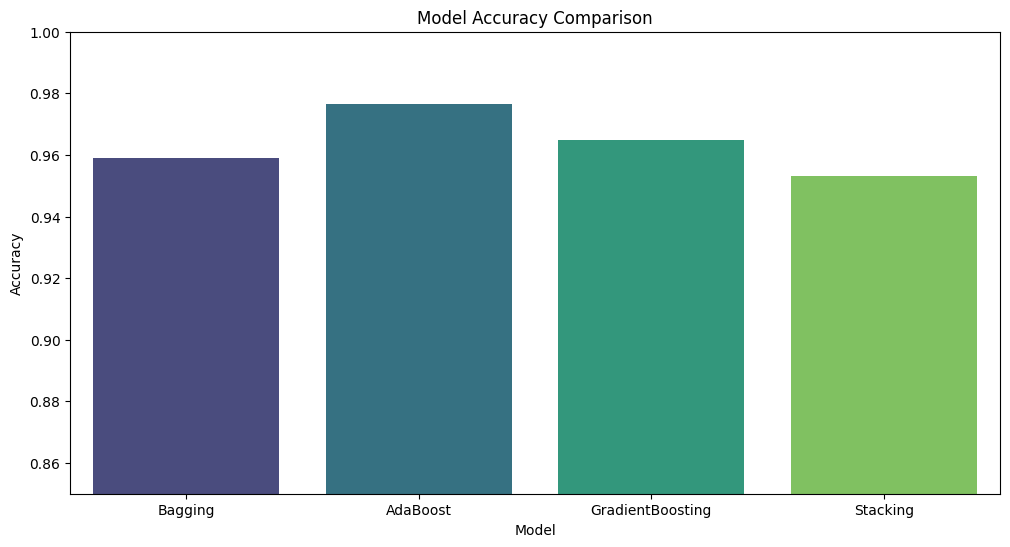

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.85, 1.0) # Set y-axis limit to highlight differences
plt.show()

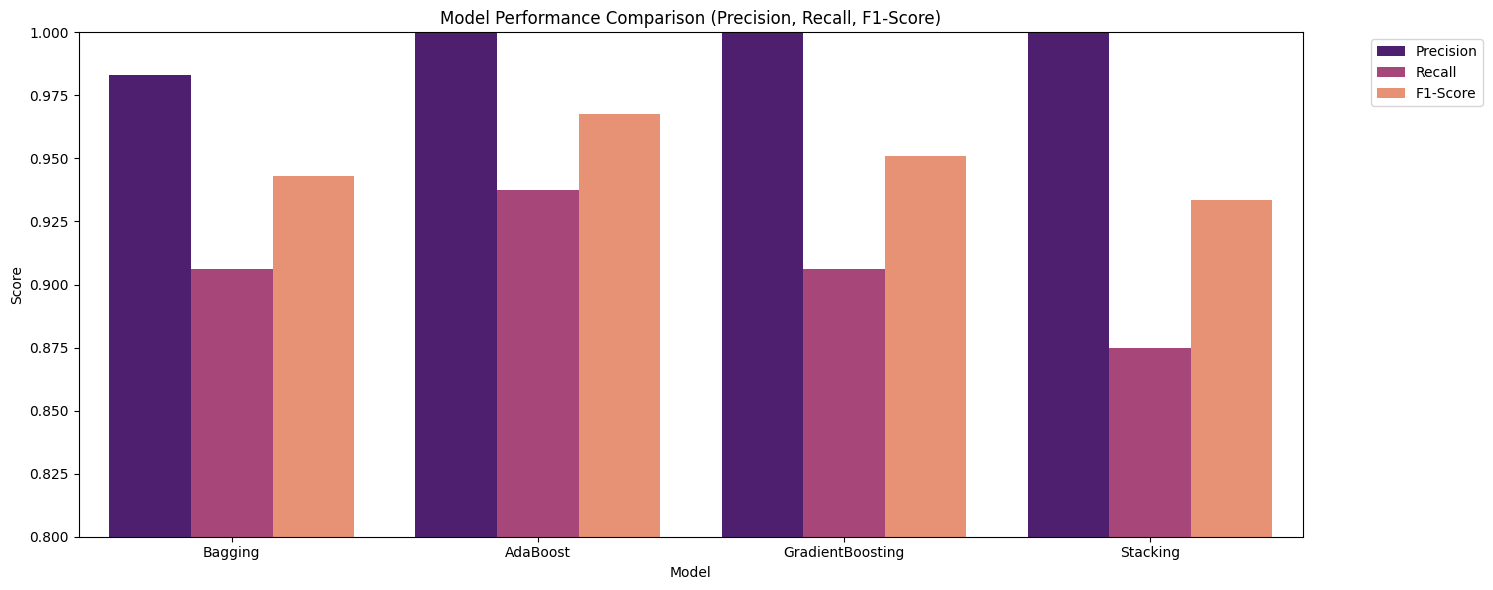

In [ ]:
plt.figure(figsize=(15, 6))
metrics = ['Precision', 'Recall', 'F1-Score']
results_melted = results_df.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')
sns.barplot(x='Model', y='Score', hue='Metric', data=results_melted, palette='magma')
plt.title('Model Performance Comparison (Precision, Recall, F1-Score)')
plt.ylabel('Score')
plt.ylim(0.8, 1.0) # Set y-axis limit to highlight differences
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()